# Multivariate Time-Series Anomaly Detection

## Project Overview

The goal of this project is to build an anomaly detection system that can identify abnormal patterns in multivariate telemetry/sensor time-series data.

Anomaly detection is important in real-world systems because abnormal behavior can indicate equipment failure, system instability, cyber-physical attacks, data quality issues, or early warning signs before a major incident occurs.

In this project, I will start by understanding and preparing the dataset, then build baseline anomaly detection models before moving to more advanced sequence-based models.

## Problem Statement

Given historical telemetry readings from a system, the objective is dataGiven historical telemetry readings from a system, the objective is to detect abnormal behavior in future readings.
- It is time-series based
- It contains labeled anomalies for evaluation
- It supports both simple baseline methods and more advanced sequence-based models
- It is relevant to practical monitoring use cases such as equipment monitoring, system health monitoring, and preventive maintenance

## Project Workflow

The project will follow these main stages:

1. Data collection
2. Data understanding
3. Exploratory data analysis
4. Data preprocessing
5. Feature engineering
6. Baseline anomaly detection models
7. Advanced anomaly detection models
8. Model evaluation
9. Error analysis and conclusions

## Evaluation Metrics

Since anomaly detection datasets are usually imbalanced, accuracy will not be the main metric.

The main evaluation metrics will include:

- Precision
- Recall
- F1-score
- Precision-Recall AUC
- False alarm rate

## Current Notebook Objective

This notebook focuses on the first stage of the project: data understanding.

The main questions to answer in this notebook are:

- What files are available in the dataset?
- What is the shape of the training data, test data, and labels?
- How many telemetry channels/features exist?
- How many anomaly points exist?
- What percentage of the test data is anomalous?
- Can we visualize sample telemetry channels and highlight anomaly regions?

The model should produce either:

- An anomaly score, where higher values indicate more abnormal behavior
- A binary prediction:
  - `0` = normal
  - `1` = anomaly

## Dataset

The planned dataset for this project is the NASA SMAP/MSL anomaly detection dataset.

This dataset contains telemetry readings from spacecraft/rover systems and includes labeled anomaly intervals, making it suitable for evaluating anomaly detection methods.

## Dataset Sources: SMAP and MSL

The dataset contains telemetry data from two NASA systems:

- **SMAP** stands for **Soil Moisture Active Passive**. It is a NASA Earth satellite mission designed to measure Earth’s soil moisture and freeze/thaw state.
- **MSL** stands for **Mars Science Laboratory**. It is NASA’s Mars rover mission associated with the Curiosity rover.

In this project, SMAP and MSL are used only as sources of telemetry time-series data. The goal is not to study soil moisture or Mars science directly, but to detect abnormal patterns in the telemetry signals produced by these systems.
``

## Why This Dataset?

This dataset is suitable for this project because:



## Dataset Structure

After downloading the NASA SMAP/MSL anomaly detection dataset, the raw data folder contains:

- `labeled_anomalies.xlsx`: metadata file containing the labeled anomaly intervals for different telemetry channels.
- `train/`: training telemetry data.
- `test/`: test telemetry data.
- Additional folders such as `models/`, `smoothed_errors/`, and `y_hat/`, which appear to contain outputs from an existing model pipeline.

For this project, I will focus on building my own end-to-end anomaly detection pipeline using the raw training data, raw test data, and labeled anomaly metadata.

The initial data preparation goal is to:

1. Inspect the available train and test files.
2. Understand the structure of the labeled anomalies file.
3. Select one telemetry channel with labeled anomalies.
4. Load its train and test data.
5. Convert anomaly intervals into binary labels.
6. Visualize the signal and its anomaly regions.

### Visualization (One Channel Example)
A Channel is a specific telemetry feature (e.g., temperature, pressure, etc.) that is being monitored over time. Each channel has its own time-series data and corresponding anomaly labels.

In [4]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

train_dir = r"C:\Users\user\OneDrive - TechnoVal\Desktop\Scripts\ML\anomaly-detection-project\data\raw\train"
test_dir = r"C:\Users\user\OneDrive - TechnoVal\Desktop\Scripts\ML\anomaly-detection-project\data\raw\test"

channel_id = "A-1"

train_path = os.path.join(train_dir,f"{channel_id}.npy")
test_path = os.path.join(test_dir,f"{channel_id}.npy")

train_data = np.load(train_path)
test_data = np.load(test_path)


print("Channel:", channel_id)
print("Train shape:", train_data.shape)
print("Test shape:", test_data.shape)
print("Train dimensions:", train_data.ndim)
print("Test dimensions:", test_data.ndim)



Channel: A-1
Train shape: (2880, 25)
Test shape: (8640, 25)
Train dimensions: 2
Test dimensions: 2


## Understanding the Labeled Anomalies Metadata

The dataset includes a metadata table with the following columns:

- `chan_id`: the telemetry channel identifier, matching `.npy` files in the train and test folders.
- `spacecraft`: the source system, either SMAP or MSL.
- `anomaly_sequences`: the labeled anomalous time ranges in the test signal.
- `class`: the anomaly type, such as point or contextual.
- `num_values`: the number of time steps in the test signal.

Each row describes the anomaly labels for one telemetry channel. The anomaly sequences refer to index ranges in the corresponding test file.

For example, channel `A-1` has the anomaly sequence `[[4690, 4774]]`, meaning that time steps from 4690 to 4774 in `test/A-1.npy` are labeled as anomalous.

For the first detailed analysis, I will start with channel `A-1` because it has a simple single anomaly interval and is suitable for validating the label creation and visualization pipeline.

## Anomaly Types: Point and Contextual

The dataset classifies anomalies into two main types:

- **Point anomaly**: a telemetry value or short range of values that is clearly abnormal on its own. These anomalies are often easier to detect using simple thresholds, alarms, or distance-based methods.

- **Contextual anomaly**: a value or sequence that may not look abnormal by itself, but becomes abnormal because of its surrounding time context or pattern. These anomalies usually require sequence-aware methods because the model needs to understand how the signal behaves over time.

For example, a sudden extreme spike can be considered a point anomaly, while a value that looks normal but appears at the wrong time or breaks the expected signal pattern can be considered a contextual anomaly.

Channel: A-1
Train shape: (2880, 25)
Test shape: (8640, 25)
Number of test points: 8640
Number of anomalous points: 84
Anomaly percentage: 0.97 %


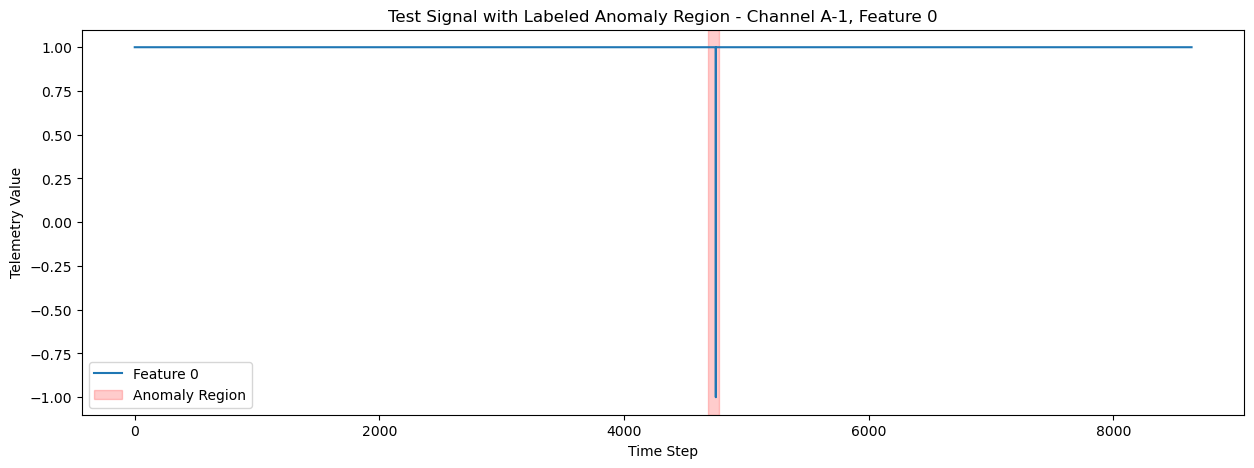

In [10]:
import os
import ast
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

DATA_DIR = r"C:\Users\user\OneDrive - TechnoVal\Desktop\Scripts\ML\anomaly-detection-project\data\raw"

train_dir = os.path.join(DATA_DIR, "train")
test_dir = os.path.join(DATA_DIR, "test")

channel_id = "A-1"

train_path = os.path.join(train_dir, f"{channel_id}.npy")
test_path = os.path.join(test_dir, f"{channel_id}.npy")

train_signal = np.load(train_path).squeeze()
test_signal = np.load(test_path).squeeze()


print("Channel:", channel_id)
print("Train shape:", train_signal.shape)
print("Test shape:", test_signal.shape)

# Creating anomaly label array manually first channel A-1 based on the provided anomaly intervals
A_1_anomaly = [[4690, 4774]]

test_labels = np.zeros(len(test_signal), dtype=int)
for start, end in A_1_anomaly:
    test_labels[start:end] = 1


print("Number of test points:", len(test_signal))
print("Number of anomalous points:", test_labels.sum())
print("Anomaly percentage:", round(test_labels.mean() * 100, 2), "%")

# Visualize the signal and anomalies
feature_idx = 0

test_feature = test_signal[:, feature_idx]

plt.figure(figsize=(15, 5))

plt.plot(test_feature, label=f"Feature {feature_idx}")

for i, (start, end) in enumerate(A_1_anomaly):
    label = "Anomaly Region" if i == 0 else None
    plt.axvspan(start, end, color="red", alpha=0.2, label=label)

plt.title(f"Test Signal with Labeled Anomaly Region - Channel {channel_id}, Feature {feature_idx}")
plt.xlabel("Time Step")
plt.ylabel("Telemetry Value")
plt.legend()
plt.show()

### Zooming Into The Anomaly Region 
To better understand the anomaly, I will zoom into the specific time range of the anomaly interval and visualize the signal in that region. This will help me see how the signal behaves around the anomaly and whether it is a point or contextual anomaly.

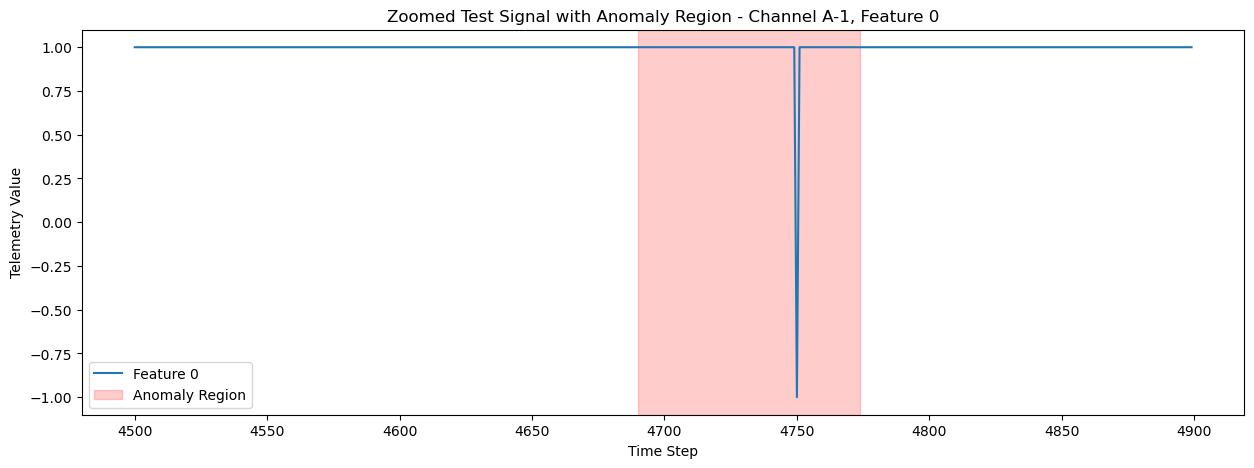

In [12]:
feature_idx = 0

start_zoom = 4500
end_zoom = 4900

test_feature = test_signal[:, feature_idx]

plt.figure(figsize=(15, 5))

plt.plot(
    range(start_zoom, end_zoom),
    test_feature[start_zoom:end_zoom],
    label=f"Feature {feature_idx}"
)

for i, (start, end) in enumerate(A_1_anomaly):
    label = "Anomaly Region" if i == 0 else None
    plt.axvspan(start, end, color="red", alpha=0.2, label=label)

plt.title(f"Zoomed Test Signal with Anomaly Region - Channel {channel_id}, Feature {feature_idx}")
plt.xlabel("Time Step")
plt.ylabel("Telemetry Value")
plt.legend()
plt.show()

The zoomed plot for channel `A-1`, feature `0`, shows that the feature is mostly constant at value `1.0`. Within the labeled anomaly interval `[4690, 4774]`, there is a sharp drop to approximately `-1.0` around time step `4750`.

This confirms that the labeled anomaly region aligns with a visible abnormal change in at least one feature. However, the anomaly label applies to the full time interval and to the full multivariate row, not only to feature `0`.

### Now I will find exactly where Feature 0 changes  

In [13]:
feature_idx = 0

test_feature = test_signal[:, feature_idx]

anomaly_start, anomaly_end = A_1_anomaly[0]

anomaly_feature_values = test_feature[anomaly_start:anomaly_end + 1]

print("Anomaly interval:", anomaly_start, anomaly_end)
print("Unique values inside anomaly interval:", np.unique(anomaly_feature_values))
print("Minimum value inside anomaly interval:", anomaly_feature_values.min())
print("Maximum value inside anomaly interval:", anomaly_feature_values.max())

drop_indices = np.where(test_feature == -1)[0]

print("Indices where Feature 0 equals -1:")
print(drop_indices)

Anomaly interval: 4690 4774
Unique values inside anomaly interval: [-1.  1.]
Minimum value inside anomaly interval: -1.0
Maximum value inside anomaly interval: 1.0
Indices where Feature 0 equals -1:
[4750]


### Now I will plot several features together to see if the anomaly is visible in multiple features or just one.

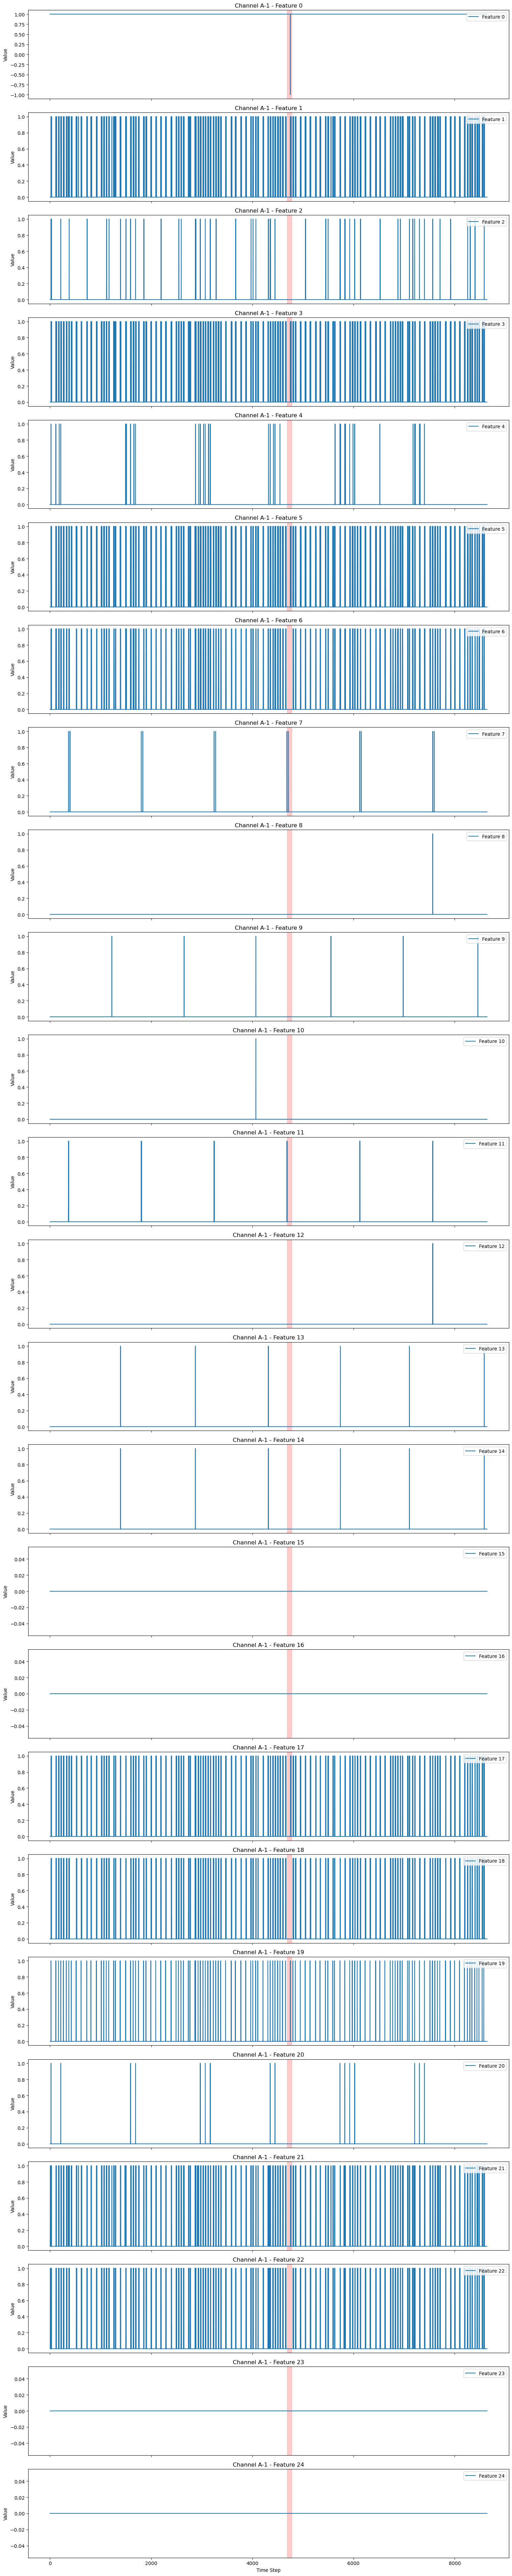

In [15]:
num_features_to_plot = 25

fig, axes = plt.subplots(num_features_to_plot, 1, figsize=(15, 3 * num_features_to_plot), sharex=True)

for feature_idx in range(num_features_to_plot):
    feature_values = test_signal[:, feature_idx]
    
    axes[feature_idx].plot(feature_values, label=f"Feature {feature_idx}")
    
    for start, end in A_1_anomaly:
        axes[feature_idx].axvspan(start, end, color="red", alpha=0.2)
    
    axes[feature_idx].set_title(f"Channel {channel_id} - Feature {feature_idx}")
    axes[feature_idx].set_ylabel("Value")
    axes[feature_idx].legend(loc="upper right")

axes[-1].set_xlabel("Time Step")

plt.tight_layout()
plt.show()

For channel `A-1`, the labeled anomaly interval is `[4690, 4774]`.

Feature `0` is mostly constant at value `1.0`, but it drops to `-1.0` at exactly time step `4750`, which lies inside the labeled anomaly interval. This suggests that the anomaly is clearly visible in Feature `0`.

After plotting all 25 features for channel `A-1`, Feature `0` shows the clearest visible anomaly. It is mostly constant at `1.0`, but drops to `-1.0` at time step `4750`, which lies inside the labeled anomaly interval `[4690, 4774]`.

Many other features appear to be binary or sparse indicator-like variables that switch between `0` and `1`. Some features are almost constant and may provide limited information for anomaly detection.

This confirms that the anomaly label is aligned with the time dimension, not with a specific feature. The labeled anomaly interval marks anomalous time steps, while individual features may show the anomaly with different levels of visibility.

In [ ]:
feature_summary = pd.DataFrame({
    "feature_index": range(test_signal.shape[1]),
    "mean": test_signal.mean(axis=0),
    "std": test_signal.std(axis=0),
    "min": test_signal.min(axis=0),
    "max": test_signal.max(axis=0),
    "unique_values": [len(np.unique(test_signal[:, i])) for i in range(test_signal.shape[1])]
})

feature_summary
feature_summary.sort_values("std", ascending=False)



,feature_index,mean,std,min,max,unique_values
15,15,0.0,0.0,0.0,0.0,1
16,16,0.0,0.0,0.0,0.0,1
23,23,0.0,0.0,0.0,0.0,1
24,24,0.0,0.0,0.0,0.0,1


Other plotted features appear to behave like binary or sparse indicator features, switching between `0` and `1`. The anomaly is not equally visible across all features, which is expected in multivariate anomaly detection. The label applies to the full time step, while individual features may show the anomaly with different levels of visibility.

In [18]:
constant_features = feature_summary[feature_summary["std"] == 0]

constant_features

,feature_index,mean,std,min,max,unique_values
15,15,0.0,0.0,0.0,0.0,1
16,16,0.0,0.0,0.0,0.0,1
23,23,0.0,0.0,0.0,0.0,1
24,24,0.0,0.0,0.0,0.0,1


In [19]:
binary_like_features = feature_summary[feature_summary["unique_values"] <= 2]

binary_like_features

,feature_index,mean,std,min,max,unique_values
0,0,0.999769,0.021515,-1.0,1.0,2
1,1,0.036806,0.188284,0.0,1.0,2
2,2,0.009375,0.096370,0.0,1.0,2
3,3,0.028241,0.165660,0.0,1.0,2
4,4,0.004167,0.064415,0.0,1.0,2
5,5,0.170139,0.375755,0.0,1.0,2
6,6,0.135185,0.341921,0.0,1.0,2
7,7,0.001389,0.037242,0.0,1.0,2
8,8,0.000116,0.010758,0.0,1.0,2
9,9,0.000694,0.026343,0.0,1.0,2


Create the final test labels array for A-1, where `1` indicates an anomaly and `0` indicates normal.

In [20]:
test_labels = np.zeros(test_signal.shape[0], dtype=int)

for start, end in A_1_anomaly:
    test_labels[start:end + 1] = 1

print("Test signal shape:", test_signal.shape)
print("Test labels shape:", test_labels.shape)
print("Number of anomalous time steps:", test_labels.sum())
print("Anomaly percentage:", round(test_labels.mean() * 100, 2), "%")

Test signal shape: (8640, 25)
Test labels shape: (8640,)
Number of anomalous time steps: 85
Anomaly percentage: 0.98 %


A-1 is a multivariate time-series sample with 8640 time steps and 25 features. The labeled anomaly interval is from 4690 to 4774. Feature 0 shows a clear abnormal drop at time step 4750, while other features are mostly binary, sparse, or constant. The label applies to the time steps, not to individual feature columns.